Using device: mps
Evaluating on 304 samples from Test set.
Running Ensemble Inference...


Members: 100%|██████████| 3/3 [00:27<00:00,  9.28s/it]


Calculating Calibration Metrics...


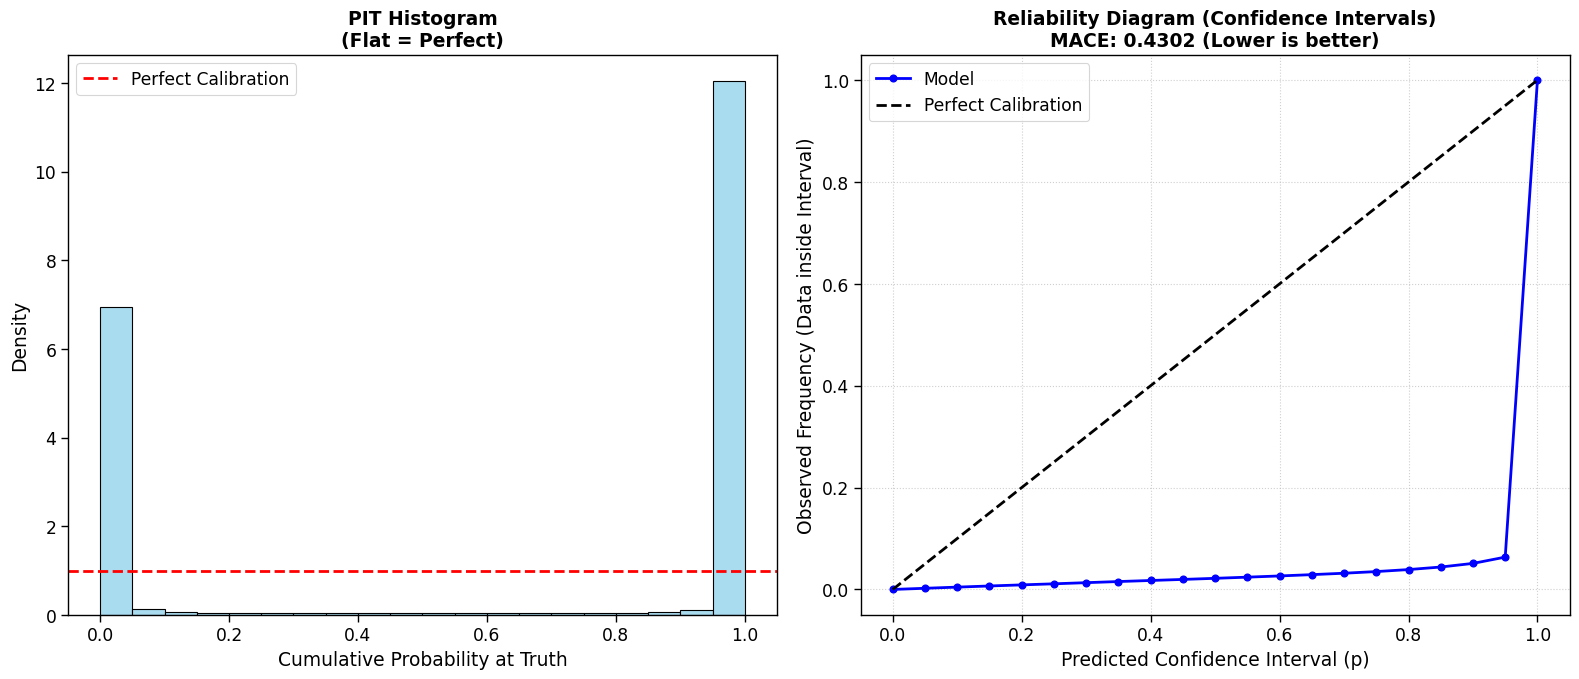

In [4]:
import glob
import json
import os
import numpy as np
import xarray as xr
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

from unet import ProbUNet

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
# Set a limit to speed up analysis (None = use all test samples)
NUM_SAMPLES = None
BATCH_SIZE = 20

# Lat/Lon dimensions
lat_dim = 128
num_bins = 64

# Model Architecture Config (Must match training)
base_channels = 200
gn_groups = 1
kernel_size = 3

dP_min = -700
dP_max = 1200

# Paths
base_dir = Path("/Users/ewellmeyer/Documents/research")
data_dir = base_dir / "HadGEM"
input_file = data_dir / f"GA789_PR_his_rg{lat_dim}.nc"
truth_file = data_dir / f"GA789_dPdK_rg{lat_dim}.nc"
landmask_file = data_dir / "hadgem_landmask_rg128.nc"

# Ensemble Directory
ens_name = (
    f"unet_ens_HG789_PR_dPdK_Softmax_unet6R_ch{base_channels}_k{kernel_size}_"
    f"{lat_dim}x_dPbins{num_bins}_gn{gn_groups}_dpmin{dP_min}_dPmax{dP_max}"
)
ens_dir = Path("/Users/ewellmeyer/Documents/research/weights") / ens_name
norm_stats_path = ens_dir / "norm_stats.json"
bin_info_path   = ens_dir / "born_bins.json"
split_ind_path  = ens_dir / "data_splits.npz"

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# ==============================================================================
# 2. DATA LOADING
# ==============================================================================
def load_data():
    # Load Stats
    with open(norm_stats_path, "r") as f:
        ns = json.load(f)
    x_mean = np.array(ns["x_mean"], dtype=np.float32).reshape(1, 1, 1, 1)
    x_std  = np.array(ns["x_std"],  dtype=np.float32).reshape(1, 1, 1, 1)
    y_mean = float(ns["y_mean"])
    y_std  = float(ns["y_std"])

    # Load Bin Centers
    with open(bin_info_path, "r") as f:
        bi = json.load(f)
    bin_centers = np.array(bi["bin_centers_norm"], dtype=np.float32)

    # Load Splits
    splits = np.load(split_ind_path)
    test_indices = splits["test"]

    if NUM_SAMPLES is not None:
        if NUM_SAMPLES < len(test_indices):
            test_indices = np.random.choice(test_indices, NUM_SAMPLES, replace=False)
            test_indices.sort()

    print(f"Evaluating on {len(test_indices)} samples from Test set.")

    # Load NetCDF Data
    ds_in = xr.open_dataset(input_file)
    ds_tar = xr.open_dataset(truth_file)

    # Load Landmask
    ds_lm = xr.open_dataset(landmask_file)
    landmask = ds_lm['land_mask'].values.astype(bool)

    # Extract arrays: (N, 1, H, W)
    X_full = ds_in.to_array().values.astype(np.float32)
    y_full = ds_tar.to_array().values.astype(np.float32)
    X_full = np.transpose(X_full, (1, 0, 2, 3))
    y_full = np.transpose(y_full, (1, 0, 2, 3))

    ds_in.close()
    ds_tar.close()
    ds_lm.close()

    # Select Test Data
    X_test = X_full[test_indices]
    y_test = y_full[test_indices]

    # Normalize
    X_test_norm = (X_test - x_mean) / x_std
    y_test_norm = (y_test - y_mean) / y_std

    return X_test_norm, y_test_norm, bin_centers, landmask, y_mean, y_std

# ==============================================================================
# 3. ENSEMBLE INFERENCE & CDF CALCULATION
# ==============================================================================
def get_predicted_cdfs(X_norm, bin_centers):
    """
    Returns the Cumulative Distribution Function (CDF) for every pixel
    averaged across the ensemble.
    """
    member_files = sorted(glob.glob(str(ens_dir / f"{ens_dir.name}_member*.pth")))
    if not member_files:
        raise ValueError(f"No checkpoint files found in {ens_dir}")

    N, _, H, W = X_norm.shape
    accum_probs = np.zeros((N, num_bins, H, W), dtype=np.float32)

    model = ProbUNet(1, base_channels, kernel_size, 0.0, num_bins, gn_groups=gn_groups).to(device)

    print("Running Ensemble Inference...")
    for m_file in tqdm(member_files, desc="Members"):
        ckpt = torch.load(m_file, map_location=device)
        state = ckpt["model"] if "model" in ckpt else ckpt
        model.load_state_dict(state, strict=False)
        model.eval()

        with torch.inference_mode():
            for i in range(0, N, BATCH_SIZE):
                batch_X = torch.as_tensor(X_norm[i:i+BATCH_SIZE], dtype=torch.float32, device=device)
                probs = model.forward_components(batch_X).float()
                accum_probs[i:i+BATCH_SIZE] += probs.cpu().numpy()

    # Average probabilities across members
    avg_probs = accum_probs / len(member_files)

    # CDF via cumulative sum over bin dimension (axis 1): (N, num_bins, H, W)
    cdf = np.cumsum(avg_probs, axis=1)
    cdf[:, -1, :, :] = 1.0  # fix float accumulation errors

    return cdf

# ==============================================================================
# 4. CALCULATE RELIABILITY (PIT HISTOGRAM & INTERVAL CALIBRATION)
# ==============================================================================
def calculate_calibration(cdf, y_true_norm, bin_centers, landmask):
    """
    Probability Integral Transform (PIT).
    For a calibrated model, the CDF value at the true observation
    should be uniformly distributed U[0,1].
    """
    print("Calculating Calibration Metrics...")

    # Flatten land pixels in a consistent (sample, pixel, bin) order.
    # The previous direct reshape scrambled the bin axis relative to y_flat.
    y_flat = y_true_norm[:, 0][:, landmask].reshape(-1)
    cdf_flat = np.transpose(cdf, (0, 2, 3, 1))[:, landmask, :].reshape(-1, num_bins)

    n_points = len(y_flat)

    # Interpolate CDF to find probability at true value (PIT)
    idx = np.searchsorted(bin_centers, y_flat)
    idx = np.clip(idx, 1, num_bins - 1)

    x0 = bin_centers[idx - 1]
    x1 = bin_centers[idx]
    y0 = cdf_flat[np.arange(n_points), idx - 1]
    y1 = cdf_flat[np.arange(n_points), idx]

    pit_values = y0 + (y_flat - x0) * (y1 - y0) / (x1 - x0)
    pit_values = np.clip(pit_values, 0.0, 1.0)

    return pit_values

# ==============================================================================
# 5. PLOTTING
# ==============================================================================
def plot_reliability(pit_values):
    sns.set_context("paper", font_scale=1.4)
    fig, ax = plt.subplots(1, 2, figsize=(16, 7))

    # PIT Histogram
    sns.histplot(pit_values, bins=20, stat='density', ax=ax[0], color='skyblue', edgecolor='black', alpha=0.7)
    ax[0].axhline(1.0, color='red', linestyle='--', linewidth=2, label="Perfect Calibration")
    ax[0].set_title("PIT Histogram\n(Flat = Perfect)", fontweight='bold')
    ax[0].set_xlabel("Cumulative Probability at Truth")
    ax[0].set_ylabel("Density")
    ax[0].legend()

    # Reliability Diagram
    expected_probs = np.linspace(0, 1, 21)
    observed_freqs = []
    for p in expected_probs:
        lower_q = 0.5 - p / 2
        upper_q = 0.5 + p / 2
        count = np.sum((pit_values >= lower_q) & (pit_values <= upper_q))
        observed_freqs.append(count / len(pit_values))

    ax[1].plot(expected_probs, observed_freqs, 'o-', color='blue', linewidth=2, label='Model')
    ax[1].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')

    mace = np.mean(np.abs(np.array(observed_freqs) - expected_probs))
    ax[1].set_title(f"Reliability Diagram (Confidence Intervals)\nMACE: {mace:.4f} (Lower is better)", fontweight='bold')
    ax[1].set_xlabel("Predicted Confidence Interval (p)")
    ax[1].set_ylabel("Observed Frequency (Data inside Interval)")
    ax[1].legend()
    ax[1].grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

# ==============================================================================
# MAIN EXECUTION
# ==============================================================================
X_test, y_test, bin_centers, landmask, y_mean, y_std = load_data()
cdf = get_predicted_cdfs(X_test, bin_centers)
pit_values = calculate_calibration(cdf, y_test, bin_centers, landmask)
plot_reliability(pit_values)

Using device: mps
Validation samples: 151
Test samples:       304
Found 10 ensemble members
Accumulating ensemble probabilities for val...


val members: 100%|██████████| 10/10 [00:22<00:00,  2.27s/it]


Fitting temperature-only calibration on validation subset...
Fitting mean-preserving symmetric residual calibration...
Fitting mean-preserving asymmetric residual calibration...

Validation-fit summary:
  Temp only  | T=2.8100  CvM=1362.1457  MACE=0.1747  mean PIT=0.6218
  Symmetric  | s=0.7000  CvM=1294.7350  MACE=0.0416  mean PIT=0.6754
  Asymmetric | slo=0.7000  shi=0.7000  CvM=1294.7350  MACE=0.0416  mean PIT=0.6754


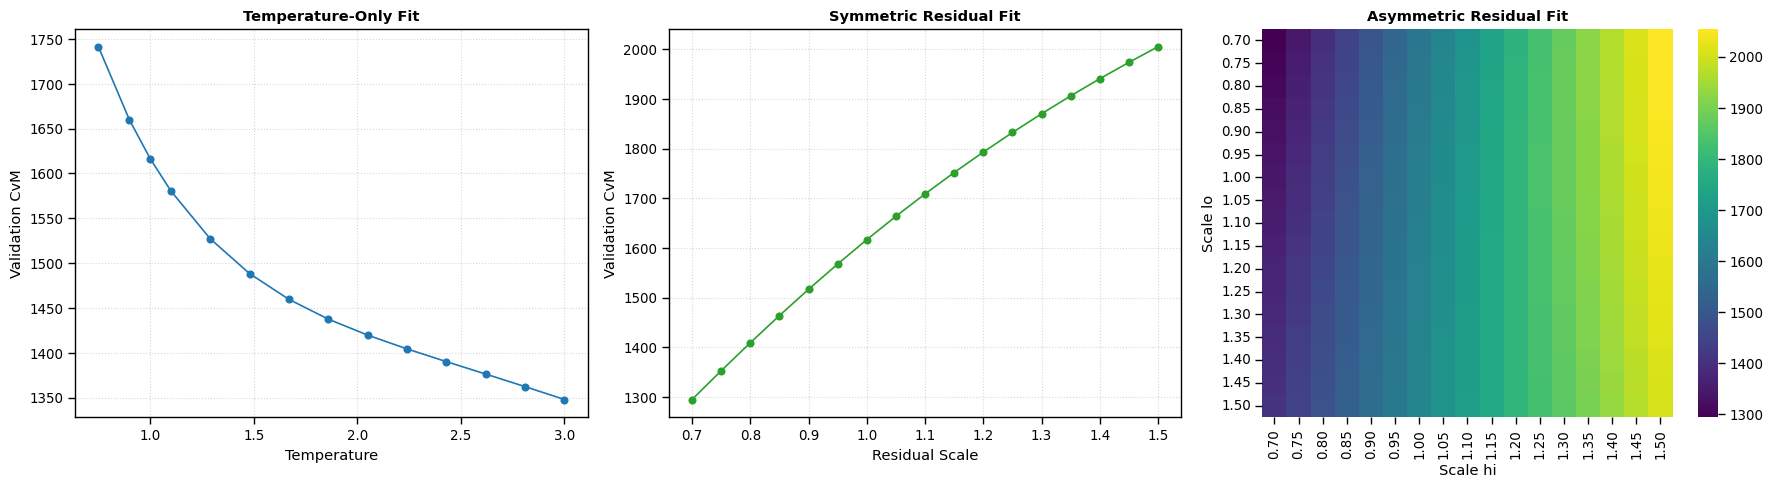

Accumulating ensemble probabilities for test...


eval asymmetric: 100%|██████████| 16/16 [00:11<00:00,  1.45it/s]



Test split summary:
  Raw           | MACE=0.0664  mean PIT=0.6921  global RMSE=46.3364  land RMSE=41.3395  mean error=-0.0522
  Temp only     | MACE=0.1723  mean PIT=0.6251  global RMSE=49.8882  land RMSE=47.4920  mean error=7.7762
  Symmetric     | MACE=0.0422  mean PIT=0.6814  global RMSE=46.3364  land RMSE=41.3395  mean error=-0.0522
  Asymmetric    | MACE=0.0422  mean PIT=0.6814  global RMSE=46.3364  land RMSE=41.3395  mean error=-0.0522


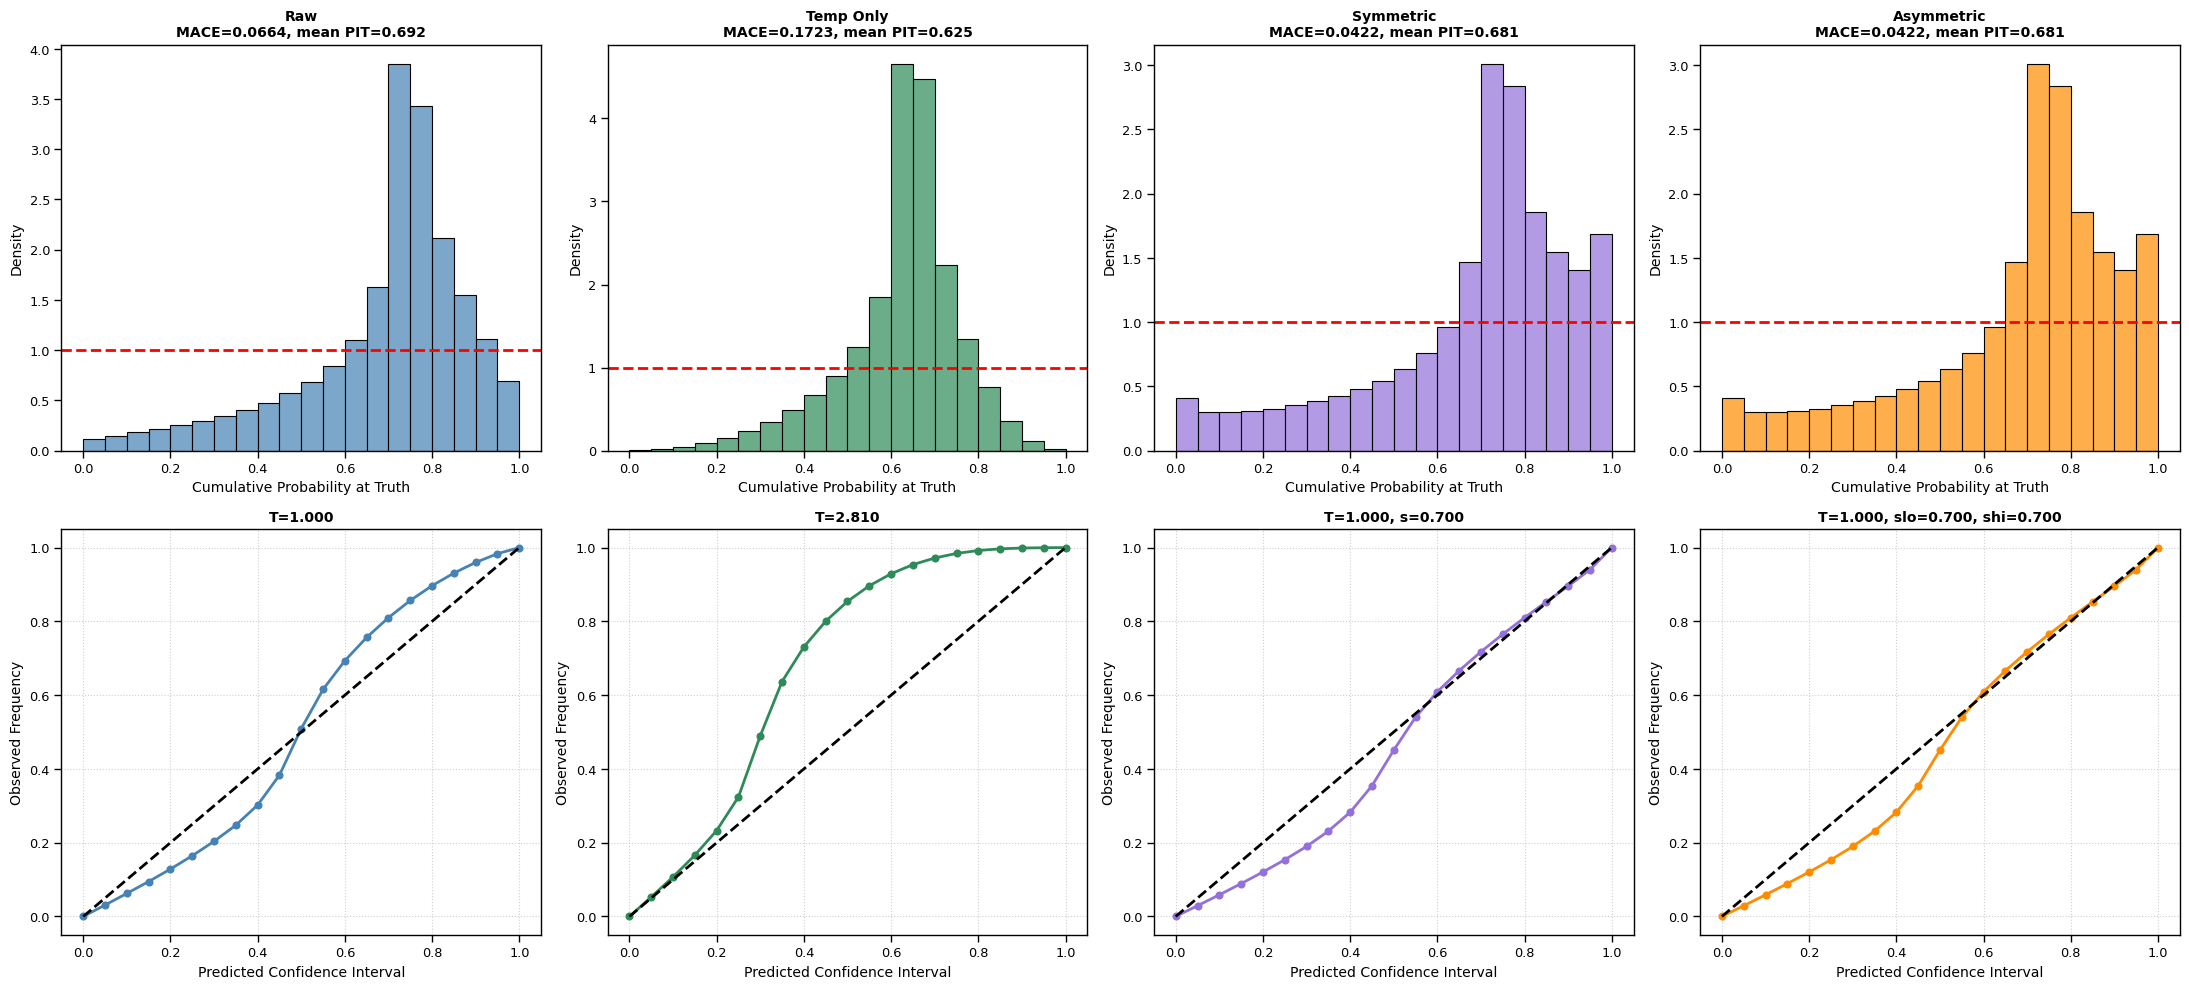


Saved calibration summary to /Users/ewellmeyer/Documents/research/weights/unet_ens_HG789_PR_dPdK_Softmax_unet6R_ch200_k3_128x_dPbins64_gn1_dpmin-700_dPmax1200/temperature_calibration.json


In [1]:
r"""
Post-hoc calibration for softmax ProbUNet outputs.

This workflow compares four variants:
  1. Raw ensemble probabilities
  2. Temperature scaling only
  3. Mean-preserving symmetric residual calibration
  4. Mean-preserving asymmetric residual calibration

The residual calibrations preserve the raw predictive mean and only adjust the
shape of the distribution around that mean:

  Symmetric:
      c'_i = mu_raw + s * (c_i - mu_raw)

  Asymmetric:
      c'_i = mu_raw + s_lo * (c_i - mu_raw),  if c_i < mu_raw
      c'_i = mu_raw + s_hi * (c_i - mu_raw),  if c_i >= mu_raw

where:
  - c_i is the original normalized bin center
  - mu_raw is the raw predictive mean in normalized units
  - s, s_lo, s_hi are residual spread corrections

This is meant to improve calibration while avoiding the RMSE damage caused by a
global affine shift of the full target axis.
"""

import glob
import json
import os
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import xarray as xr
from tqdm import tqdm

from unet import ProbUNet


# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
NUM_VAL_SAMPLES = None
NUM_TEST_SAMPLES = None
BATCH_SIZE = 20
RNG_SEED = 42

lat_dim = 128
num_bins = 64
base_channels = 200
gn_groups = 1
kernel_size = 3

dP_min = -700
dP_max = 1200

FIT_LAND_POINTS = 30000

TEMP_GRID = np.unique(
    np.concatenate(
        [
            np.array([0.75, 0.9, 1.0], dtype=np.float32),
            np.linspace(1.1, 3.0, 11, dtype=np.float32),
        ]
    )
)
SCALE_GRID = np.linspace(0.70, 1.50, 17, dtype=np.float32)
EXPECTED_PROBS = np.linspace(0.0, 1.0, 21, dtype=np.float32)

base_dir = Path("/Users/ewellmeyer/Documents/research")
data_dir = base_dir / "HadGEM"
weights_dir = base_dir / "weights"

input_file = data_dir / f"GA789_PR_his_rg{lat_dim}.nc"
truth_file = data_dir / f"GA789_dPdK_rg{lat_dim}.nc"
landmask_file = data_dir / "hadgem_landmask_rg128.nc"

ens_name = (
    f"unet_ens_HG789_PR_dPdK_Softmax_unet6R_ch{base_channels}_k{kernel_size}_"
    f"{lat_dim}x_dPbins{num_bins}_gn{gn_groups}_dpmin{dP_min}_dPmax{dP_max}"
)
ens_dir = weights_dir / ens_name

norm_stats_path = ens_dir / "norm_stats.json"
bin_info_path = ens_dir / "born_bins.json"
split_ind_path = ens_dir / "data_splits.npz"
calibration_out_path = ens_dir / "temperature_calibration.json"

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")


# ==============================================================================
# 2. DATA LOADING
# ==============================================================================
def maybe_subsample(indices, limit, seed_offset=0):
    if limit is None or limit >= len(indices):
        return np.asarray(indices)
    rng = np.random.default_rng(RNG_SEED + seed_offset)
    return np.sort(rng.choice(indices, size=limit, replace=False))


def load_data():
    with open(norm_stats_path, "r") as f:
        stats = json.load(f)
    x_mean = np.array(stats["x_mean"], dtype=np.float32).reshape(1, 1, 1, 1)
    x_std = np.array(stats["x_std"], dtype=np.float32).reshape(1, 1, 1, 1)
    y_mean = float(stats["y_mean"])
    y_std = float(stats["y_std"])

    with open(bin_info_path, "r") as f:
        bin_info = json.load(f)
    bin_centers = np.array(bin_info["bin_centers_norm"], dtype=np.float32)

    splits = np.load(split_ind_path)
    val_indices = maybe_subsample(splits["val"], NUM_VAL_SAMPLES, seed_offset=1)
    test_indices = maybe_subsample(splits["test"], NUM_TEST_SAMPLES, seed_offset=2)

    ds_in = xr.open_dataset(input_file)
    ds_tar = xr.open_dataset(truth_file)
    ds_lm = xr.open_dataset(landmask_file)

    X_full = ds_in.to_array().values.astype(np.float32)
    y_full = ds_tar.to_array().values.astype(np.float32)
    X_full = np.transpose(X_full, (1, 0, 2, 3))
    y_full = np.transpose(y_full, (1, 0, 2, 3))
    landmask = ds_lm["land_mask"].values.astype(bool)

    ds_in.close()
    ds_tar.close()
    ds_lm.close()

    X_full_norm = (X_full - x_mean) / x_std
    y_full_norm = (y_full - y_mean) / y_std

    print(f"Validation samples: {len(val_indices)}")
    print(f"Test samples:       {len(test_indices)}")

    return {
        "X_val": X_full_norm[val_indices],
        "y_val": y_full_norm[val_indices],
        "X_test": X_full_norm[test_indices],
        "y_test": y_full_norm[test_indices],
        "bin_centers": bin_centers,
        "landmask": landmask,
        "y_mean": y_mean,
        "y_std": y_std,
    }


# ==============================================================================
# 3. ENSEMBLE INFERENCE
# ==============================================================================
def get_member_files():
    member_files = sorted(glob.glob(str(ens_dir / f"{ens_dir.name}_member*.pth")))
    if not member_files:
        raise RuntimeError(f"No checkpoint files found in {ens_dir}")
    print(f"Found {len(member_files)} ensemble members")
    return member_files


def make_prob_memmap(split_name, X_norm, member_files):
    N, _, H, W = X_norm.shape
    tmp = tempfile.NamedTemporaryFile(
        prefix=f"{split_name}_avg_probs_",
        suffix=".dat",
        dir="/tmp",
        delete=False,
    )
    tmp.close()

    avg_probs = np.memmap(tmp.name, dtype=np.float32, mode="w+", shape=(N, num_bins, H, W))
    avg_probs[:] = 0.0

    model = ProbUNet(1, base_channels, kernel_size, 0.0, num_bins, gn_groups=gn_groups).to(device)

    print(f"Accumulating ensemble probabilities for {split_name}...")
    for m_file in tqdm(member_files, desc=f"{split_name} members"):
        ckpt = torch.load(m_file, map_location=device)
        state = ckpt["model"] if "model" in ckpt else ckpt
        model.load_state_dict(state, strict=False)
        model.eval()

        with torch.inference_mode():
            for i in range(0, N, BATCH_SIZE):
                xb = torch.as_tensor(X_norm[i : i + BATCH_SIZE], dtype=torch.float32, device=device)
                probs = model.forward_components(xb).float().cpu().numpy()
                avg_probs[i : i + probs.shape[0]] += probs / len(member_files)

        avg_probs.flush()

    return tmp.name, (N, num_bins, H, W)


# ==============================================================================
# 4. CALIBRATION HELPERS
# ==============================================================================
def apply_temperature_points(point_probs, temperature):
    if np.isclose(float(temperature), 1.0):
        return point_probs

    log_probs = np.log(np.clip(point_probs, 1e-12, 1.0)).astype(np.float32)
    scaled = log_probs / np.float32(temperature)
    scaled -= scaled.max(axis=1, keepdims=True)
    scaled = np.exp(scaled)
    scaled /= scaled.sum(axis=1, keepdims=True)
    return scaled.astype(np.float32)


def apply_temperature_map(probs, temperature):
    if np.isclose(float(temperature), 1.0):
        return probs

    log_probs = np.log(np.clip(probs, 1e-12, 1.0)).astype(np.float32)
    scaled = log_probs / np.float32(temperature)
    scaled -= scaled.max(axis=1, keepdims=True)
    scaled = np.exp(scaled)
    scaled /= scaled.sum(axis=1, keepdims=True)
    return scaled.astype(np.float32)


def raw_mean_from_point_probs(point_probs, centers):
    return (point_probs * centers[None, :]).sum(axis=1)


def raw_mean_from_map_probs(probs, centers):
    return (probs * centers[None, :, None, None]).sum(axis=1)


def symmetric_residual_centers(mu_raw, centers, scale):
    return mu_raw[:, None] + np.float32(scale) * (centers[None, :] - mu_raw[:, None])


def asymmetric_residual_centers(point_probs, mu_raw, centers, scale_lo, scale_hi):
    residual = centers[None, :] - mu_raw[:, None]
    scales = np.where(residual < 0.0, np.float32(scale_lo), np.float32(scale_hi))
    centers_new = mu_raw[:, None] + scales * residual
    mu_new = (point_probs * centers_new).sum(axis=1, keepdims=True)
    return centers_new + (mu_raw[:, None] - mu_new)


def asymmetric_residual_centers_map(probs, mu_raw, centers, scale_lo, scale_hi):
    residual = centers[None, :, None, None] - mu_raw[:, None, :, :]
    scales = np.where(residual < 0.0, np.float32(scale_lo), np.float32(scale_hi))
    centers_new = mu_raw[:, None, :, :] + scales * residual
    mu_new = (probs * centers_new).sum(axis=1, keepdims=True)
    return centers_new + (mu_raw[:, None, :, :] - mu_new)


def point_probs_to_pit(point_probs, y_points, centers_per_point):
    cdf = np.cumsum(point_probs, axis=1)
    cdf[:, -1] = 1.0

    idx = np.sum(y_points[:, None] >= centers_per_point, axis=1)
    idx = np.clip(idx, 1, point_probs.shape[1] - 1)

    x0 = centers_per_point[np.arange(len(y_points)), idx - 1]
    x1 = centers_per_point[np.arange(len(y_points)), idx]
    y0 = cdf[np.arange(len(y_points)), idx - 1]
    y1 = cdf[np.arange(len(y_points)), idx]
    pit = y0 + (y_points - x0) * (y1 - y0) / np.maximum(x1 - x0, 1e-12)
    return np.clip(pit, 0.0, 1.0)


def map_probs_to_pit(probs, y_true_norm, centers_per_point, landmask):
    cdf = np.cumsum(probs, axis=1)
    cdf[:, -1, :, :] = 1.0

    y_flat = y_true_norm[:, 0][:, landmask].reshape(-1)
    cdf_flat = np.transpose(cdf, (0, 2, 3, 1))[:, landmask, :].reshape(-1, num_bins)
    centers_flat = centers_per_point[:, landmask].reshape(-1, 1)

    # Rebuild centers row-wise around the local raw mean.
    # This function expects centers_per_point to be (N, H, W) raw means; the
    # actual calibrated centers are derived by the caller before invoking it.
    raise NotImplementedError


def mace_from_pit(pit_values):
    counts = np.zeros(len(EXPECTED_PROBS), dtype=np.int64)
    for i, p in enumerate(EXPECTED_PROBS):
        lower_q = 0.5 - p / 2.0
        upper_q = 0.5 + p / 2.0
        counts[i] = np.sum((pit_values >= lower_q) & (pit_values <= upper_q))
    observed = counts / max(len(pit_values), 1)
    mace = np.mean(np.abs(observed - EXPECTED_PROBS))
    return float(mace), observed


def cvm_from_pit(pit_values):
    if len(pit_values) == 0:
        return float("inf")
    u = np.sort(np.asarray(pit_values, dtype=np.float64))
    n = len(u)
    grid = (2.0 * np.arange(1, n + 1) - 1.0) / (2.0 * n)
    return float((1.0 / (12.0 * n)) + np.sum((u - grid) ** 2))


def select_best(rows, primary_key="cvm", tie_key="point_rmse_norm", rel_tol=0.02):
    best_primary = min(row[primary_key] for row in rows)
    cutoff = best_primary * (1.0 + rel_tol) + 1e-12
    candidates = [row for row in rows if row[primary_key] <= cutoff]
    return min(candidates, key=lambda row: (row[tie_key], abs(row["mean_pit"] - 0.5)))


def point_mean_stats(point_probs, y_points, centers_per_point):
    mu = (point_probs * centers_per_point).sum(axis=1)
    diff = mu - y_points
    return {
        "point_rmse_norm": float(np.sqrt(np.mean(diff ** 2))),
        "point_bias_norm": float(np.mean(diff)),
    }


# ==============================================================================
# 5. FIT ON VALIDATION SUBSET
# ==============================================================================
def sample_val_points(prob_path, prob_shape, y_val_norm, landmask, max_points):
    prob_mm = np.memmap(prob_path, dtype=np.float32, mode="r", shape=prob_shape)

    land_i, land_j = np.where(landmask)
    n_land = len(land_i)
    total_points = prob_shape[0] * n_land
    n_take = min(max_points, total_points)

    rng = np.random.default_rng(RNG_SEED)
    flat_idx = np.sort(rng.choice(total_points, size=n_take, replace=False))
    sample_idx = flat_idx // n_land
    land_idx = flat_idx % n_land
    ii = land_i[land_idx]
    jj = land_j[land_idx]

    point_probs = np.asarray(prob_mm[sample_idx, :, ii, jj], dtype=np.float32)
    y_points = np.asarray(y_val_norm[sample_idx, 0, ii, jj], dtype=np.float32)
    return point_probs, y_points


def fit_temp_only(point_probs, y_points, bin_centers):
    rows = []
    print("Fitting temperature-only calibration on validation subset...")
    for temperature in TEMP_GRID:
        probs_t = apply_temperature_points(point_probs, temperature)
        pit = point_probs_to_pit(probs_t, y_points, np.broadcast_to(bin_centers[None, :], probs_t.shape))
        stats = point_mean_stats(probs_t, y_points, np.broadcast_to(bin_centers[None, :], probs_t.shape))
        rows.append(
            {
                "temperature": float(temperature),
                "scale": 1.0,
                "scale_lo": 1.0,
                "scale_hi": 1.0,
                "cvm": cvm_from_pit(pit),
                "mace": mace_from_pit(pit)[0],
                "mean_pit": float(pit.mean()),
                **stats,
            }
        )
    return select_best(rows), rows


def fit_symmetric(point_probs, y_points, bin_centers):
    rows = []
    print("Fitting mean-preserving symmetric residual calibration...")
    mu_raw = raw_mean_from_point_probs(point_probs, bin_centers)
    for scale in SCALE_GRID:
        centers = symmetric_residual_centers(mu_raw, bin_centers, scale)
        pit = point_probs_to_pit(point_probs, y_points, centers)
        stats = point_mean_stats(point_probs, y_points, centers)
        rows.append(
            {
                "temperature": 1.0,
                "scale": float(scale),
                "scale_lo": float(scale),
                "scale_hi": float(scale),
                "cvm": cvm_from_pit(pit),
                "mace": mace_from_pit(pit)[0],
                "mean_pit": float(pit.mean()),
                **stats,
            }
        )
    return select_best(rows), rows


def fit_asymmetric(point_probs, y_points, bin_centers):
    rows = []
    print("Fitting mean-preserving asymmetric residual calibration...")
    mu_raw = raw_mean_from_point_probs(point_probs, bin_centers)
    for scale_lo in SCALE_GRID:
        for scale_hi in SCALE_GRID:
            centers = asymmetric_residual_centers(point_probs, mu_raw, bin_centers, scale_lo, scale_hi)
            pit = point_probs_to_pit(point_probs, y_points, centers)
            stats = point_mean_stats(point_probs, y_points, centers)
            rows.append(
                {
                    "temperature": 1.0,
                    "scale": 1.0,
                    "scale_lo": float(scale_lo),
                    "scale_hi": float(scale_hi),
                    "cvm": cvm_from_pit(pit),
                    "mace": mace_from_pit(pit)[0],
                    "mean_pit": float(pit.mean()),
                    **stats,
                }
            )
    return select_best(rows), rows


# ==============================================================================
# 6. FULL TEST EVALUATION
# ==============================================================================
def evaluate_variant(prob_path, prob_shape, y_true_norm, bin_centers, landmask, y_mean, y_std, temperature, mode, scale=1.0, scale_lo=1.0, scale_hi=1.0):
    prob_mm = np.memmap(prob_path, dtype=np.float32, mode="r", shape=prob_shape)

    pits = []
    global_sse = 0.0
    land_sse = 0.0
    global_n = 0
    land_n = 0
    sum_error = 0.0
    sum_land_error = 0.0
    observed_counts = np.zeros(len(EXPECTED_PROBS), dtype=np.int64)

    for i in tqdm(range(0, prob_shape[0], BATCH_SIZE), desc=f"eval {mode}"):
        probs = np.asarray(prob_mm[i : i + BATCH_SIZE])
        probs_t = apply_temperature_map(probs, temperature)
        y_batch = y_true_norm[i : i + BATCH_SIZE]
        mu_raw = raw_mean_from_map_probs(probs, bin_centers)

        if mode == "raw" or mode == "temp":
            centers = np.broadcast_to(
                bin_centers[None, :, None, None],
                (probs.shape[0], num_bins, probs.shape[2], probs.shape[3]),
            )
        elif mode == "symmetric":
            centers = mu_raw[:, None, :, :] + np.float32(scale) * (bin_centers[None, :, None, None] - mu_raw[:, None, :, :])
        elif mode == "asymmetric":
            centers = asymmetric_residual_centers_map(
                probs_t, mu_raw, bin_centers, scale_lo, scale_hi
            )
        else:
            raise ValueError(f"Unknown mode: {mode}")

        cdf = np.cumsum(probs_t, axis=1)
        cdf[:, -1, :, :] = 1.0

        y_flat = y_batch[:, 0][:, landmask].reshape(-1)
        cdf_flat = np.transpose(cdf, (0, 2, 3, 1))[:, landmask, :].reshape(-1, num_bins)
        centers_flat = np.transpose(centers, (0, 2, 3, 1))[:, landmask, :].reshape(-1, num_bins)

        idx = np.sum(y_flat[:, None] >= centers_flat, axis=1)
        idx = np.clip(idx, 1, num_bins - 1)
        x0 = centers_flat[np.arange(len(y_flat)), idx - 1]
        x1 = centers_flat[np.arange(len(y_flat)), idx]
        y0 = cdf_flat[np.arange(len(y_flat)), idx - 1]
        y1 = cdf_flat[np.arange(len(y_flat)), idx]
        pit_batch = y0 + (y_flat - x0) * (y1 - y0) / np.maximum(x1 - x0, 1e-12)
        pit_batch = np.clip(pit_batch, 0.0, 1.0)
        pits.append(pit_batch)

        for j, p in enumerate(EXPECTED_PROBS):
            lower_q = 0.5 - p / 2.0
            upper_q = 0.5 + p / 2.0
            observed_counts[j] += np.sum((pit_batch >= lower_q) & (pit_batch <= upper_q))

        mu_norm = (probs_t * centers).sum(axis=1)
        truth_norm = y_batch[:, 0]
        mu = mu_norm * y_std + y_mean
        truth = truth_norm * y_std + y_mean
        diff = mu - truth

        global_sse += float((diff ** 2).sum())
        land_sse += float(((diff ** 2) * landmask[None]).sum())
        global_n += diff.size
        land_n += diff.shape[0] * int(landmask.sum())
        sum_error += float(diff.sum())
        sum_land_error += float((diff * landmask[None]).sum())

    pits = np.concatenate(pits)
    observed = observed_counts / max(len(pits), 1)
    mace = np.mean(np.abs(observed - EXPECTED_PROBS))

    return {
        "temperature": float(temperature),
        "mode": mode,
        "scale": float(scale),
        "scale_lo": float(scale_lo),
        "scale_hi": float(scale_hi),
        "pit": pits,
        "mace": float(mace),
        "observed": observed,
        "mean_pit": float(pits.mean()),
        "global_rmse": float(np.sqrt(global_sse / max(global_n, 1))),
        "land_rmse": float(np.sqrt(land_sse / max(land_n, 1))),
        "mean_error": float(sum_error / max(global_n, 1)),
        "land_mean_error": float(sum_land_error / max(land_n, 1)),
    }


# ==============================================================================
# 7. PLOTTING
# ==============================================================================
def plot_fit_diagnostics(temp_rows, sym_rows, asym_rows):
    sns.set_context("paper", font_scale=1.1)
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))

    ax[0].plot([row["temperature"] for row in temp_rows], [row["cvm"] for row in temp_rows], marker="o")
    ax[0].set_title("Temperature-Only Fit", fontweight="bold")
    ax[0].set_xlabel("Temperature")
    ax[0].set_ylabel("Validation CvM")
    ax[0].grid(True, linestyle=":", alpha=0.5)

    ax[1].plot([row["scale"] for row in sym_rows], [row["cvm"] for row in sym_rows], marker="o", color="tab:green")
    ax[1].set_title("Symmetric Residual Fit", fontweight="bold")
    ax[1].set_xlabel("Residual Scale")
    ax[1].set_ylabel("Validation CvM")
    ax[1].grid(True, linestyle=":", alpha=0.5)

    asym_grid = np.full((len(SCALE_GRID), len(SCALE_GRID)), np.nan, dtype=np.float32)
    idx_map = {float(v): i for i, v in enumerate(SCALE_GRID)}
    for row in asym_rows:
        asym_grid[idx_map[row["scale_lo"]], idx_map[row["scale_hi"]]] = row["cvm"]
    sns.heatmap(
        asym_grid,
        ax=ax[2],
        cmap="viridis",
        cbar=True,
        xticklabels=[f"{v:.2f}" for v in SCALE_GRID],
        yticklabels=[f"{v:.2f}" for v in SCALE_GRID],
    )
    ax[2].set_title("Asymmetric Residual Fit", fontweight="bold")
    ax[2].set_xlabel("Scale hi")
    ax[2].set_ylabel("Scale lo")

    plt.tight_layout()
    plt.show()


def plot_reliability_quad(raw, temp_only, symmetric, asymmetric):
    sns.set_context("paper", font_scale=1.05)
    fig, ax = plt.subplots(2, 4, figsize=(22, 10))

    variants = [
        ("Raw", raw, "steelblue"),
        ("Temp Only", temp_only, "seagreen"),
        ("Symmetric", symmetric, "mediumpurple"),
        ("Asymmetric", asymmetric, "darkorange"),
    ]

    for col, (title, result, color) in enumerate(variants):
        sns.histplot(result["pit"], bins=20, stat="density", ax=ax[0, col], color=color, edgecolor="black", alpha=0.7)
        ax[0, col].axhline(1.0, color="red", linestyle="--", linewidth=2)
        ax[0, col].set_title(
            f"{title}\nMACE={result['mace']:.4f}, mean PIT={result['mean_pit']:.3f}",
            fontweight="bold",
        )
        ax[0, col].set_xlabel("Cumulative Probability at Truth")
        ax[0, col].set_ylabel("Density")

        ax[1, col].plot(EXPECTED_PROBS, result["observed"], "o-", color=color, linewidth=2)
        ax[1, col].plot([0, 1], [0, 1], "k--", linewidth=2)
        if title == "Symmetric":
            subtitle = f"T={result['temperature']:.3f}, s={result['scale']:.3f}"
        elif title == "Asymmetric":
            subtitle = f"T={result['temperature']:.3f}, slo={result['scale_lo']:.3f}, shi={result['scale_hi']:.3f}"
        else:
            subtitle = f"T={result['temperature']:.3f}"
        ax[1, col].set_title(subtitle, fontweight="bold")
        ax[1, col].set_xlabel("Predicted Confidence Interval")
        ax[1, col].set_ylabel("Observed Frequency")
        ax[1, col].grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()


# ==============================================================================
# 8. MAIN EXECUTION
# ==============================================================================
data = load_data()
member_files = get_member_files()
val_prob_path = None
test_prob_path = None

try:
    val_prob_path, val_prob_shape = make_prob_memmap("val", data["X_val"], member_files)
    point_probs, y_points = sample_val_points(
        val_prob_path,
        val_prob_shape,
        data["y_val"],
        data["landmask"],
        FIT_LAND_POINTS,
    )

    temp_best, temp_rows = fit_temp_only(point_probs, y_points, data["bin_centers"])
    sym_best, sym_rows = fit_symmetric(point_probs, y_points, data["bin_centers"])
    asym_best, asym_rows = fit_asymmetric(point_probs, y_points, data["bin_centers"])

    print("\nValidation-fit summary:")
    print(
        f"  Temp only  | T={temp_best['temperature']:.4f}  "
        f"CvM={temp_best['cvm']:.4f}  MACE={temp_best['mace']:.4f}  "
        f"mean PIT={temp_best['mean_pit']:.4f}"
    )
    print(
        f"  Symmetric  | s={sym_best['scale']:.4f}  "
        f"CvM={sym_best['cvm']:.4f}  MACE={sym_best['mace']:.4f}  "
        f"mean PIT={sym_best['mean_pit']:.4f}"
    )
    print(
        f"  Asymmetric | slo={asym_best['scale_lo']:.4f}  shi={asym_best['scale_hi']:.4f}  "
        f"CvM={asym_best['cvm']:.4f}  MACE={asym_best['mace']:.4f}  "
        f"mean PIT={asym_best['mean_pit']:.4f}"
    )

    plot_fit_diagnostics(temp_rows, sym_rows, asym_rows)

    test_prob_path, test_prob_shape = make_prob_memmap("test", data["X_test"], member_files)

    raw_result = evaluate_variant(
        test_prob_path, test_prob_shape, data["y_test"], data["bin_centers"],
        data["landmask"], data["y_mean"], data["y_std"], 1.0, "raw"
    )
    temp_result = evaluate_variant(
        test_prob_path, test_prob_shape, data["y_test"], data["bin_centers"],
        data["landmask"], data["y_mean"], data["y_std"], temp_best["temperature"], "temp"
    )
    sym_result = evaluate_variant(
        test_prob_path, test_prob_shape, data["y_test"], data["bin_centers"],
        data["landmask"], data["y_mean"], data["y_std"], 1.0, "symmetric", scale=sym_best["scale"]
    )
    asym_result = evaluate_variant(
        test_prob_path, test_prob_shape, data["y_test"], data["bin_centers"],
        data["landmask"], data["y_mean"], data["y_std"], 1.0, "asymmetric",
        scale_lo=asym_best["scale_lo"], scale_hi=asym_best["scale_hi"]
    )

    print("\nTest split summary:")
    for label, result in [
        ("Raw", raw_result),
        ("Temp only", temp_result),
        ("Symmetric", sym_result),
        ("Asymmetric", asym_result),
    ]:
        print(
            f"  {label:13s} | MACE={result['mace']:.4f}  "
            f"mean PIT={result['mean_pit']:.4f}  "
            f"global RMSE={result['global_rmse']:.4f}  "
            f"land RMSE={result['land_rmse']:.4f}  "
            f"mean error={result['mean_error']:.4f}"
        )

    plot_reliability_quad(raw_result, temp_result, sym_result, asym_result)

    with open(calibration_out_path, "w") as f:
        json.dump(
            {
                "fit_land_points": int(len(y_points)),
                "temperature_grid": TEMP_GRID.tolist(),
                "scale_grid": SCALE_GRID.tolist(),
                "validation_temp_only_best": temp_best,
                "validation_symmetric_best": sym_best,
                "validation_asymmetric_best": asym_best,
                "test_raw": {
                    "mace": raw_result["mace"],
                    "mean_pit": raw_result["mean_pit"],
                    "global_rmse": raw_result["global_rmse"],
                    "land_rmse": raw_result["land_rmse"],
                    "mean_error": raw_result["mean_error"],
                },
                "test_temp_only": {
                    "temperature": temp_result["temperature"],
                    "mace": temp_result["mace"],
                    "mean_pit": temp_result["mean_pit"],
                    "global_rmse": temp_result["global_rmse"],
                    "land_rmse": temp_result["land_rmse"],
                    "mean_error": temp_result["mean_error"],
                },
                "test_symmetric": {
                    "scale": sym_result["scale"],
                    "mace": sym_result["mace"],
                    "mean_pit": sym_result["mean_pit"],
                    "global_rmse": sym_result["global_rmse"],
                    "land_rmse": sym_result["land_rmse"],
                    "mean_error": sym_result["mean_error"],
                },
                "test_asymmetric": {
                    "scale_lo": asym_result["scale_lo"],
                    "scale_hi": asym_result["scale_hi"],
                    "mace": asym_result["mace"],
                    "mean_pit": asym_result["mean_pit"],
                    "global_rmse": asym_result["global_rmse"],
                    "land_rmse": asym_result["land_rmse"],
                    "mean_error": asym_result["mean_error"],
                },
            },
            f,
            indent=2,
        )

    print(f"\nSaved calibration summary to {calibration_out_path}")
finally:
    if val_prob_path and os.path.exists(val_prob_path):
        os.remove(val_prob_path)
    if test_prob_path and os.path.exists(test_prob_path):
        os.remove(test_prob_path)
